In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [16]:
def getCSV(name):
    dfl = pd.read_csv(name)
    return dfl
df = getCSV(r'C:\Users\Tom\OneDrive\Documents\APROJECTS\EthnicCork.csv') 
print(df)

                  Statistic Label  Census Year    Ethnicity  \
0     Usually resident population         2022  White Irish   
1     Usually resident population         2022  White Irish   
2     Usually resident population         2022  White Irish   
3     Usually resident population         2022  White Irish   
4     Usually resident population         2022  White Irish   
...                           ...          ...          ...   
1331  Usually resident population         2022        Total   
1332  Usually resident population         2022        Total   
1333  Usually resident population         2022        Total   
1334  Usually resident population         2022        Total   
1335  Usually resident population         2022        Total   

            CSO Local Electoral Areas 2022    UNIT    VALUE  
0     Borris-In-Ossory-Mountmellick, Laois  Number    23125  
1                        Portlaoise, Laois  Number    23498  
2      Graiguecullen -Portarlington, Laois  Number    254

In [56]:
county = "Laois"
filtered_df = df[df['CSO Local Electoral Areas 2022'].str.contains(county)]
filtered_df = filtered_df[filtered_df['Ethnicity']!="Total"]
filtered_df['CSO Local Electoral Areas 2022'] = filtered_df['CSO Local Electoral Areas 2022'].apply(lambda x: x.split(",")[0])
print(filtered_df)

                  Statistic Label  Census Year              Ethnicity  \
0     Usually resident population         2022            White Irish   
1     Usually resident population         2022            White Irish   
2     Usually resident population         2022            White Irish   
167   Usually resident population         2022  White Irish Traveller   
168   Usually resident population         2022  White Irish Traveller   
169   Usually resident population         2022  White Irish Traveller   
334   Usually resident population         2022            Other White   
335   Usually resident population         2022            Other White   
336   Usually resident population         2022            Other White   
501   Usually resident population         2022   Black or Black Irish   
502   Usually resident population         2022   Black or Black Irish   
503   Usually resident population         2022   Black or Black Irish   
668   Usually resident population         2022   As

In [57]:
def changeEthnicity(ethnicity):
    switch = {
        'Asian or Asian Irish':'Asian',
        'White Irish Traveller':'Irish Traveller',
        'Black or Black Irish':'Black'
    }
    if ethnicity not in switch:
        return ethnicity
    else:
        return switch[ethnicity]
    
filtered_df['Ethnicity'] = filtered_df['Ethnicity'].apply(changeEthnicity)

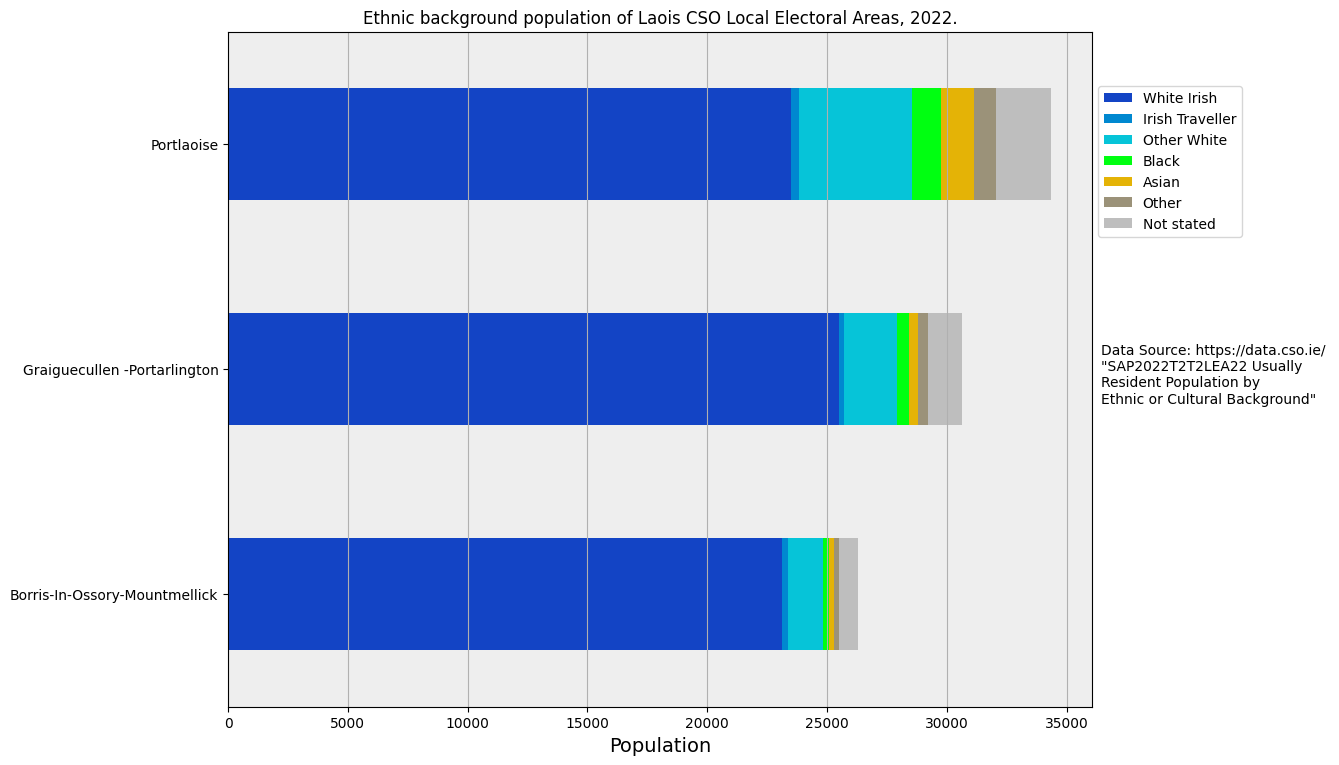

In [58]:
fig, ax = plt.subplots(1,1,figsize=(12,8))

pivot_df = filtered_df.pivot_table(index='CSO Local Electoral Areas 2022', columns='Ethnicity', values='VALUE', aggfunc='sum', fill_value=0)

desired_order = [
    "White Irish",
    "Irish Traveller",
    "Other White",
    "Black",
    "Asian",
    "Other",
    "Not stated"
]

pivot_df = pivot_df.reindex(columns=desired_order)

colors = ["#1344c5","#0088d0", "#06c4d8", "#00ff11", "#e4b306", "#9b9279", "#bebebe"]
pivot_df.plot(kind='barh', stacked=True, figsize=(12, 9), ax=ax, color=colors, width= .5)

ax.set_facecolor('#EEEEEE') 
# plt.grid(True)
plt.xlabel('Population', fontsize=14)
plt.ylabel('')
plt.grid(axis='x')
plt.legend(loc='upper left', bbox_to_anchor=(.999, .93))

plt.xticks(rotation=0)
plt.title('Ethnic background population of '+county+' CSO Local Electoral Areas, 2022.')

plt.subplots_adjust(left=0.08, right=0.8, top=0.9, bottom=0.15)
plt.text(1.01, +0.45, "Data Source: https://data.cso.ie/ \n\"SAP2022T2T2LEA22 Usually \nResident Population by \nEthnic or Cultural Background\"", ha='left', transform=ax.transAxes)

plt.savefig('Electoral-Ethnicity-'+county+'.png', bbox_inches='tight')

plt.show()